In [12]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Stil-Setup
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print(f"PyTorch: {torch.__version__}")
print(f"CUDA verfügbar: {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "mps"
print(f"{device}")

PyTorch: 2.9.1
CUDA verfügbar: False
mps


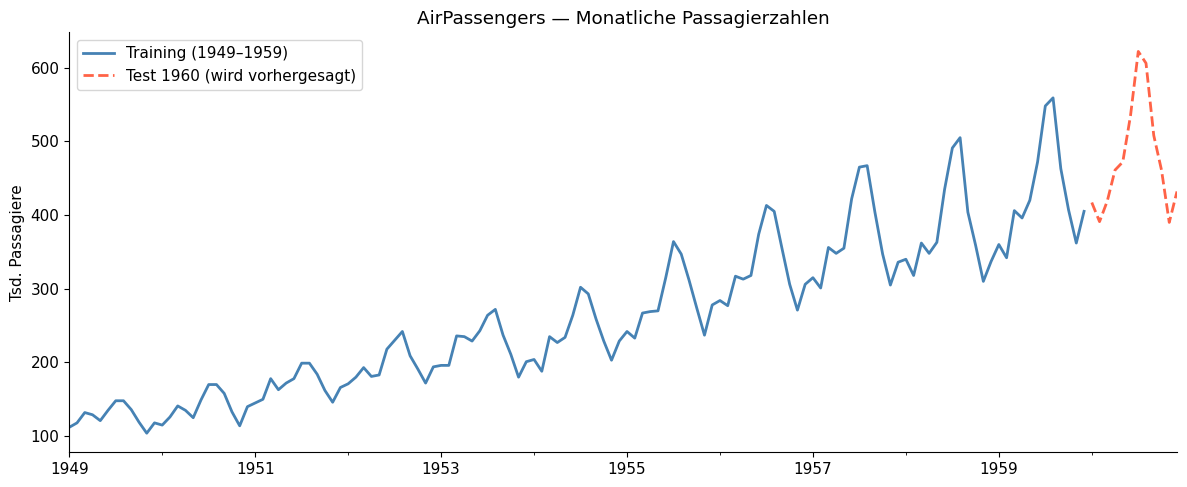

Trainingsdaten: 132 Monate
Prognose-Horizont: 12 Monate


In [13]:
# AirPassengers Datensatz (1949-1960, monatlich)
air_passengers = [
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118,  # 1949
    115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140,  # 1950
    145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166,  # 1951
    171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172, 194,  # 1952
    196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201,  # 1953
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229,  # 1954
    242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237, 278,  # 1955
    284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306,  # 1956
    315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305, 336,  # 1957
    340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337,  # 1958
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405,  # 1959
    417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432,  # 1960
]

dates = pd.date_range(start='1949-01', periods=len(air_passengers), freq='ME')
ts = pd.Series(air_passengers, index=dates, name='Passagiere (Tsd.)')

# Train/Test Split: letzte 12 Monate als Testset
n_pred = 12
ts_train = ts[:-n_pred]
ts_test = ts[-n_pred:]

fig, ax = plt.subplots()
ts_train.plot(ax=ax, label='Training (1949–1959)', color='steelblue', linewidth=2)
ts_test.plot(ax=ax, label='Test 1960 (wird vorhergesagt)', color='tomato', linewidth=2, linestyle='--')
ax.set_title('AirPassengers — Monatliche Passagierzahlen')
ax.set_ylabel('Tsd. Passagiere')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trainingsdaten: {len(ts_train)} Monate")
print(f"Prognose-Horizont: {n_pred} Monate")


In [14]:
from chronos import ChronosPipeline

# Modell laden — 'small' ist ein guter Kompromiss zwischen Geschwindigkeit und Qualität
# Optionen: tiny, mini, small, base, large
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    dtype=torch.bfloat16,  # Speichereffizient
)

In [15]:
context = torch.tensor(ts_train.values, dtype=torch.float32)

forecast = pipeline.predict(
    inputs=context.unsqueeze(0),  # Batch-Dimension hinzufügen
    prediction_length=n_pred,
    num_samples=500,
)

forecast_np = forecast.squeeze(0).numpy()  # (500, 12)

# Quantile berechnen
low   = np.quantile(forecast_np, 0.1, axis=0)
mid   = np.quantile(forecast_np, 0.5, axis=0)  # Median
high  = np.quantile(forecast_np, 0.9, axis=0)

forecast_dates = ts_test.index



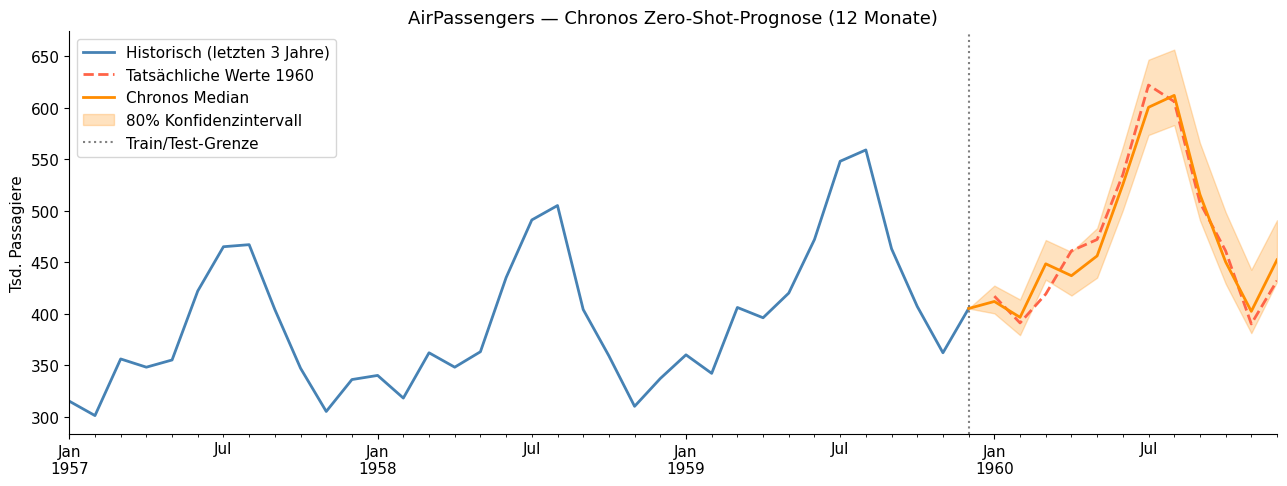

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))

# Historische Daten
ts_train[-36:].plot(ax=ax, color='steelblue', linewidth=2, label='Historisch (letzten 3 Jahre)')

# Tatsächliche Werte
ts_test.plot(ax=ax, color='tomato', linewidth=2, linestyle='--', label='Tatsächliche Werte 1960')

_hx, _hy = ax.lines[0].get_xdata(), ax.lines[0].get_ydata()
cx   = np.concatenate([[_hx[-1]], ax.lines[-1].get_xdata()])
conn = lambda y: np.concatenate([[_hy[-1]], y])
ax.plot(cx, conn(mid), color='darkorange', linewidth=2, label='Chronos Median')
ax.fill_between(cx, conn(low), conn(high), alpha=0.25, color='darkorange',
                label='80% Konfidenzintervall')

ax.axvline(ts_train.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Train/Test-Grenze')

ax.set_title('AirPassengers — Chronos Zero-Shot-Prognose (12 Monate)', fontsize=13)
ax.set_ylabel('Tsd. Passagiere')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mase(y_true, y_pred, y_train, seasonality=12):
    """Mean Absolute Scaled Error: MAE normalisiert durch saisonale Naive-Prognose."""
    naive_errors = np.abs(y_train[seasonality:] - y_train[:-seasonality])  # saisonale Lag-m-Differenzen
    scale = np.mean(naive_errors)
    return mae(y_true, y_pred) / scale

y_true = ts_test.values
y_pred = mid
y_train_vals = ts_train.values

results = {
    'Modell': ['Chronos Small (Zero-Shot)', 'Saisonale Naive Baseline'],
    'MAE': [
        mae(y_true, y_pred),
        mae(y_true, ts_train[-12:].values)  # Naive: letztes Jahr wiederholen
    ],
    'MAPE (%)': [
        mape(y_true, y_pred),
        mape(y_true, ts_train[-12:].values)
    ],
    'MASE': [
        mase(y_true, y_pred, y_train_vals),
        mase(y_true, ts_train[-12:].values, y_train_vals)
    ]
}

df_results = pd.DataFrame(results).set_index('Modell')
df_results = df_results.round(2)
print(df_results.to_string())

                             MAE  MAPE (%)  MASE
Modell                                          
Chronos Small (Zero-Shot)  14.01      3.01  0.46
Saisonale Naive Baseline   47.83      9.99  1.57


In [18]:
import time

modelle = {
    'tiny':  'amazon/chronos-t5-tiny',
    'small': 'amazon/chronos-t5-small',
    'base':  'amazon/chronos-t5-base',
}

vergleich = []

for name, model_id in modelle.items():
    pipe = ChronosPipeline.from_pretrained(
        model_id, device_map=device, torch_dtype=torch.bfloat16
    )
    
    t0 = time.time()
    fc = pipe.predict(context.unsqueeze(0), prediction_length=n_pred, num_samples=200)
    elapsed = time.time() - t0
    
    fc_np = fc.squeeze(0).numpy()
    pred_median = np.median(fc_np, axis=0)
    
    vergleich.append({
        'Modell': f'Chronos-{name}',
        'Parameter': {'tiny': '8M', 'small': '46M', 'base': '200M'}[name],
        'Laufzeit (s)': round(elapsed, 2),
        'MAE': round(mae(y_true, pred_median), 1),
        'MAPE (%)': round(mape(y_true, pred_median), 1),
    })

df_vergleich = pd.DataFrame(vergleich).set_index('Modell')
print(df_vergleich.to_string())

              Parameter  Laufzeit (s)   MAE  MAPE (%)
Modell                                               
Chronos-tiny         8M          0.94  20.8       4.4
Chronos-small       46M          0.44  13.7       2.9
Chronos-base       200M          0.90  11.9       2.5


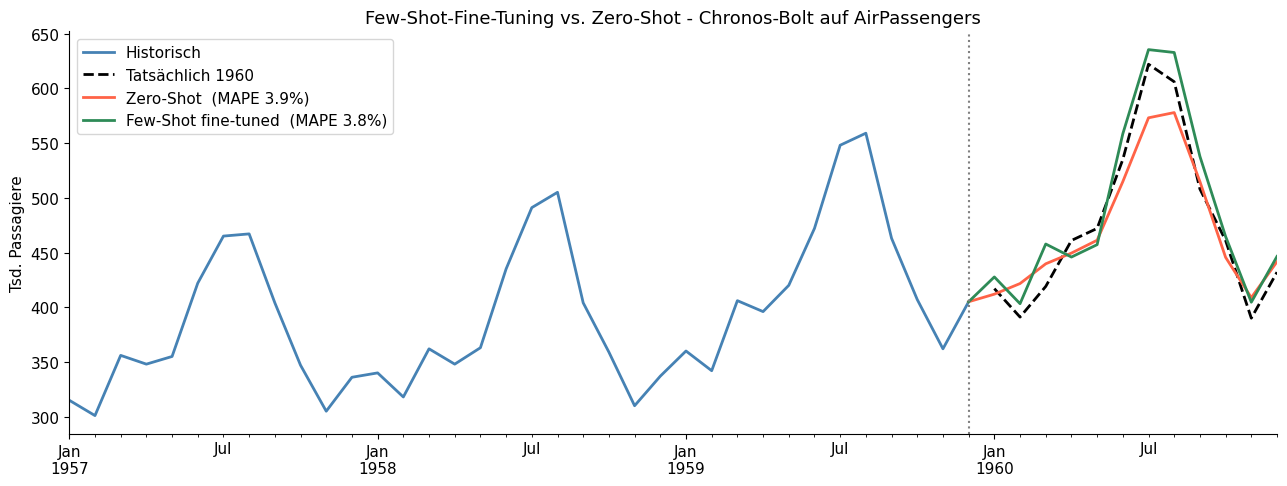

In [19]:

from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame

# Trainingsdaten ins AutoGluon-Long-Format (nur ts_train -> kein Leakage in den Test)
ag_df = pd.DataFrame({"item_id": "air", "timestamp": ts_train.index, "target": ts_train.values})
ag_train = TimeSeriesDataFrame.from_data_frame(ag_df, id_column="item_id", timestamp_column="timestamp")

predictor = TimeSeriesPredictor(prediction_length=n_pred, target="target",
                                eval_metric="MAPE", verbosity=0)
predictor.fit(ag_train, enable_ensemble=False, time_limit=600, hyperparameters={"Chronos": [
    # Zero-Shot: Basismodell ohne Anpassung
    {"model_path": "amazon/chronos-bolt-small", "fine_tune": False, "device": device,
     "ag_args": {"name_suffix": "ZeroShot"}},
    # Few-Shot: wenige Fine-Tuning-Schritte auf den vorhandenen Daten
    {"model_path": "amazon/chronos-bolt-small", "fine_tune": True,  "device": device,
     "fine_tune_steps": 1000, "fine_tune_lr": 1e-4,
     "ag_args": {"name_suffix": "FewShot"}},
]})



In [ ]:
def ag_median(model):
    fc = predictor.predict(ag_train, model=model)
    col = "mean" if "mean" in fc.columns else "0.5"
    return fc[col].to_numpy()[:n_pred]

m_zs = [m for m in predictor.model_names() if "ZeroShot" in m][0]
m_fs = [m for m in predictor.model_names() if "FewShot"  in m][0]
pred_zs, pred_fs = ag_median(m_zs), ag_median(m_fs)
mape_zs, mape_fs = mape(y_true, pred_zs), mape(y_true, pred_fs)



In [ ]:


# Visualisierung: Zero-Shot vs. Few-Shot
fig, ax = plt.subplots(figsize=(13, 5))
ts_train[-36:].plot(ax=ax, color='steelblue', linewidth=2, label='Historisch')
ts_test.plot(ax=ax, color='black', linewidth=2, linestyle='--', label='Tatsächlich 1960')

_hx, _hy = ax.lines[0].get_xdata(), ax.lines[0].get_ydata()
cx   = np.concatenate([[_hx[-1]], ax.lines[-1].get_xdata()])
conn = lambda y: np.concatenate([[_hy[-1]], y])
ax.plot(cx, conn(pred_zs), color='tomato',  linewidth=2, label=f'Zero-Shot  (MAPE {mape_zs:.1f}%)')
ax.plot(cx, conn(pred_fs), color='seagreen', linewidth=2, label=f'Few-Shot fine-tuned  (MAPE {mape_fs:.1f}%)')
ax.axvline(ts_train.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Few-Shot-Fine-Tuning vs. Zero-Shot - Chronos-Bolt auf AirPassengers', fontsize=13)
ax.set_ylabel('Tsd. Passagiere')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()